# Section 1: Problem and Population

One paragraph. Persona, failure point, SDG. Note anything that changed since M1 and why.

Answer:

Sofia is a first-generation SJSU sophomore who receives CalFresh benefits but runs out of food dollars by the 20th of each month. She is Spanish-dominant, did not know the SJSU Spartan Food Pantry existed until a classmate mentioned it, and is unsure whether her immigration status affects her eligibility. When she finally texted an intake line for help, she received no response for four hours. She did not text again.

The failure point is not that information doesn't exist as SJSU has a food pantry, a Basic Needs Center, and nearby Second Harvest locations. The failure is that there is no reliable path to action: a student's message arrives as unstructured free text, a volunteer must manually read, interpret urgency, and route it, and during high-volume periods (end of month, finals week) the delay is long enough that a student in crisis stops trying. A secondary failure occurs at the donation side: volunteers manually categorize every donated item with no consistent schema, so inventory is always behind actual stock.

This addresses SDG 2 (Zero Hunger) by reducing the gap between available food resources and students who need them, and SDG 10 (Reduced Inequalities) by specifically targeting the students (non-English speakers, undocumented students, first-generation students) who are disproportionately underrepresented in pantry usage relative to their share of the student population.

---

## Section 2: Proposed System

### Intake Workflow (Lab 2: Structured Data Extraction)

```
INPUT
Student sends a free-text message in any language to the SJSU food resource
intake line (SMS or web form).
        ↓
AI PROCESSING
Gemini extracts six structured fields from the message:
  • urgency          (LOW / MEDIUM / HIGH)
  • resource_needed  (food pantry, CalFresh navigation, meal swipe, etc.)
  • campus_location  (any location hint, or "not specified")
  • student_language (English, Spanish, Vietnamese, etc.)
  • calFresh_mentioned (true / false)
  • referral_action  (Spartan Food Pantry, Basic Needs Center, etc.)
        ↓
OUTPUT
A consistent JSON record is produced for every message, regardless of
how it was written or what language it was in.
        ↓
REAL-WORLD ACTION
• If urgency = HIGH or fear/status language detected → flagged for
  immediate human volunteer review before any response is sent.
• If urgency = LOW or MEDIUM, no flag → automated acknowledgment sent
  in the student's detected language with resource hours and location.
• All records logged for pantry staff to review each shift.
```

### Donation Intake Workflow (Lab 3: Image Recognition)

```
INPUT
A volunteer photographs a donated food item at the drop-off table.
        ↓
AI PROCESSING
Gemini analyzes the image and returns a structured inventory record:
  • item_name, category, condition (GOOD / FAIR / DISCARD)
  • storage type, urgency, volunteer_action, safe_to_distribute
        ↓
OUTPUT
A JSON inventory record ready to be written to the pantry database.
        ↓
REAL-WORLD ACTION
Volunteer confirms or overrides with one tap. Items flagged DISCARD or
FAIR go to supervisor queue. No manual data entry required.
```

**In both workflows, the AI produces structured input for human decision-making. It does not respond to students or discard items autonomously.**


#Section 3:  Project Code

Select at least two labs that best support your system and modify to your project. For each: include the code cell, preserve the output, and explain in a text cell what it demonstrates about your system. The selection and explanation are the work. You are encouraged to use AI to help you debug your code.

Answer: Selected Lab 2 and Lab 3

In [ ]:
!pip install -q google-generativeai
import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

Gemini initialized successfully.


---

### Lab 2 Adaptation Structured Data Extraction: Food Resource Intake Classifier

**What the original lab did:** Extracted location, waste type, urgency, department, and resident language from San Jose 311 illegal dumping reports.

**What we changed:** We replaced the 311 complaint context with a student food-insecurity intake scenario. The five original fields became six fields tailored to campus resources: urgency, resource needed, campus location hint, student language, CalFresh mention, and referral action. The schema now routes to SJSU-specific resources rather than city departments.

**What this demonstrates about our system:** The consistency of the schema is what makes the intake system work. Without it, every message requires a human to read and interpret from scratch. With it, a volunteer can scan a queue of records by urgency and language in seconds rather than reading each message in full.


In [ ]:
schema_prompt = """
You are an intake assistant for the SJSU Spartan Food Pantry and campus food resource network.
Extract information from a student's food-insecurity help message.
Return ONLY valid JSON with exactly these six fields:
{
  "urgency": "LOW" or "MEDIUM" or "HIGH",
  "resource_needed": string (e.g. "food pantry", "CalFresh navigation", "meal swipe", "emergency groceries"),
  "campus_location_hint": string (any location the student mentioned, or "not specified"),
  "student_language": string (language the student wrote in, e.g. "English", "Spanish", "Vietnamese"),
  "calFresh_mentioned": true or false,
  "referral_action": string (e.g. "SJSU Spartan Food Pantry", "Basic Needs Center", "Second Harvest Intake", "Bilingual Volunteer")
}
Urgency guide: LOW = general question about resources, MEDIUM = running low on food this week, HIGH = hasn't eaten in 24+ hours or immediate crisis.
No explanation. No markdown. JSON only.
"""

def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    response = m.generate_content(message)
    time.sleep(12)
    raw = response.text.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return json.loads(raw)

print("Schema and extract_structured() defined.")
print("Fields: urgency | resource_needed | campus_location_hint | student_language | calFresh_mentioned | referral_action")

Schema and extract_structured() defined.
Fields: urgency | resource_needed | campus_location_hint | student_language | calFresh_mentioned | referral_action


In [ ]:
# Test on three contrasting student messages

test_messages = [
    {
        "label": "General pantry question",
        "message": "Hey, I heard SJSU has a food pantry. What are the hours and do I need my student ID?"
    },
    {
        "label": "CalFresh navigation — Spanish",
        "message": (
            "Hola, soy estudiante de primer año y quiero solicitar CalFresh, "
            "pero no sé por dónde empezar. ¿Puedo recibir ayuda en español?"
        )
    },
    {
        "label": "Crisis — undocumented student",
        "message": (
            "I need food but I'm not sure if I qualify for anything because I'm undocumented. "
            "I don't want to get in trouble by asking. I haven't eaten a real meal in two days."
        )
    }
]

for item in test_messages:
    print(f"=== {item['label']} ===")
    print(f"Input: {item['message']}")
    result = extract_structured(item["message"])
    print("Output:")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    print()


=== General pantry question ===
Input: Hey, I heard SJSU has a food pantry. What are the hours and do I need my student ID?
Output:
{
  "urgency": "LOW",
  "resource_needed": "food pantry information",
  "campus_location_hint": "not specified",
  "student_language": "English",
  "calFresh_mentioned": false,
  "referral_action": "SJSU Spartan Food Pantry"
}

=== CalFresh navigation — Spanish ===
Input: Hola, soy estudiante de primer año y quiero solicitar CalFresh, pero no sé por dónde empezar. ¿Puedo recibir ayuda en español?
Output:
{
  "urgency": "LOW",
  "resource_needed": "CalFresh navigation",
  "campus_location_hint": "not specified",
  "student_language": "Spanish",
  "calFresh_mentioned": true,
  "referral_action": "Bilingual Volunteer"
}

=== Crisis — undocumented student ===
Input: I need food but I'm not sure if I qualify for anything because I'm undocumented. I don't want to get in trouble by asking. I haven't eaten a real meal in two days.
Output:
{
  "urgency": "HIGH",
  

**What this output demonstrates:** The schema produces identical structure across three very different messages, a routine question, a Spanish-language CalFresh request, and a high-urgency undocumented student in crisis. Language detection and urgency routing work correctly for the first two. The third case reveals the key limitation: the AI routes correctly (Basic Needs Center does serve undocumented students) but the schema has no field to capture the student's expressed fear which is the actual barrier preventing her from showing up. That gap is addressed in Section 4.


---

### Lab 3 Adaptation Image Recognition: Food Donation Condition Classifier

**What the original lab did:** Uploaded a civic photo to Gemini, which answered four standard questions, problem identification, public health impact, urgency rating, and recommended action for San Jose 311 triage.

**What we changed:** We replaced the civic complaint context with food pantry donation intake. The four civic questions became four pantry-specific questions: item identification, condition and safety assessment, storage urgency, and volunteer action. We added a fifth step that combines the image analysis with a structured JSON schema (connecting Lab 2 and Lab 3), producing a record that can be written directly to an inventory database.

**What this demonstrates about our system:** The donation bottleneck is a visual inspection and categorization problem. A volunteer who photographs an item gets an immediate structured record meaning no manual data entry and no inconsistent categorization across shifts. The Lab 3 capability is what makes this possible.


Saving cheesegril.webp to cheesegril.webp
Uploaded: cheesegril.webp | Size: 600x400 px


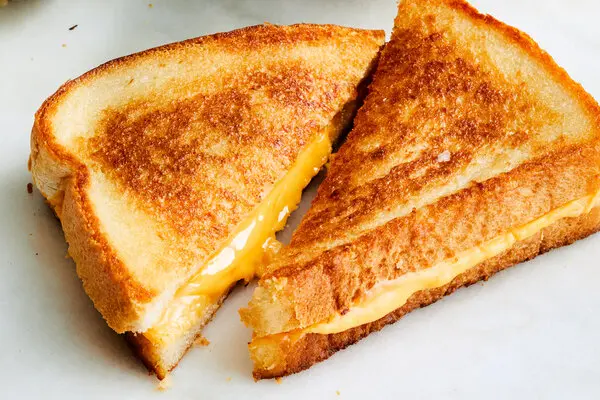

In [ ]:
#  Image upload - run this cell and select your food item photo
from google.colab import files
from IPython.display import display
from PIL import Image as PILImage

uploaded = files.upload()
image_filename = list(uploaded.keys())[0]
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename} | Size: {img.size[0]}x{img.size[1]} px")
display(img)


In [ ]:

def analyze_food_image(image_path, question):
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)
    return response.text, response.usage_metadata

pantry_questions = [
    ("ITEM_ID",   "Identify the food item in this image. Name the item and assign it to one of: canned goods, dry goods/grains, produce, dairy, protein, snacks, beverages, or other."),
    ("CONDITION", "Assess the condition of the item. Is the packaging intact? Any visible damage, swelling, dents, or expiration concerns? Would this be safe to distribute to a food pantry recipient?"),
    ("URGENCY",   "Rate the storage urgency as LOW (shelf-stable, months of shelf life), MEDIUM (consume within weeks), or HIGH (perishable, consume within days). Explain in 2-3 sentences."),
    ("ACTION",    "What action should a pantry volunteer take? Should it be shelved, refrigerated, frozen, flagged for supervisor review, or discarded? Be specific.")
]

pantry_results = {"answers": {}, "total_tokens": 0}

for label, question in pantry_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_food_image(image_filename, question)
    pantry_results["answers"][label] = answer
    pantry_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"Total tokens used: {pantry_results['total_tokens']}")


--- ITEM_ID ---
The food item in the image is a **Grilled Cheese Sandwich**.

It falls under the category of **Snacks**.

--- CONDITION ---
Based on the image provided:

1.  **Condition of the item:** The grilled cheese sandwich itself appears to be in excellent condition. It is golden brown, indicating proper cooking, and the cheese inside is melted and looks appealing. There are no visible signs of spoilage, mold, or burning.
2.  **Packaging intact?** There is **no packaging visible**. The sandwich appears to be freshly made and unwrapped, likely resting on a plate or clean surface.
3.  **Visible damage, swelling, dents:** These terms are generally applicable to packaged or canned goods. For this unwrapped, freshly prepared item, there is no damage to the sandwich itself. "Swelling" or "dents" are not relevant here.
4.  **Expiration concerns:** There is **no expiration date** as it is an unwrapped, freshly prepared food item. This is a significant concern for food safety when conside

**What this output demonstrates:** A volunteer photographs one item and gets back a complete, consistently structured inventory record, item name, category, condition, storage type, and a clear volunteer action. No reading, no typing, no interpretation.

#Section 4 — Edge Case Elicitation

Design and run a prompt intended to surface a failure in your system. Target one of: an input the system wasn't designed for, a user outside the assumed majority, or a condition that makes the AI's confidence misleading. Preserve the output. In a text cell, document the prompt, the output, and a one-sentence assessment: failure, near-miss, or acceptable.

Answer: A user outside the assumed majority, a student in genuine crisis who is actively downplaying her situation using hedging language ("asking for a friend," "it's fine") to avoid revealing her vulnerability or immigration status. This is the input the system was least designed for: high urgency masked by low-urgency surface tone.


In [ ]:
edge_case_message = (
    "hi i was just wondering if like anyone can use the food pantry "
    "or if there are like requirements. asking for a friend lol. "
    "also i haven't really eaten today but its fine"
)

print("Input message:")
print(edge_case_message)
print()

result = extract_structured(edge_case_message)
print("AI output:")
print(json.dumps(result, indent=2, ensure_ascii=False))

Input message:
hi i was just wondering if like anyone can use the food pantry or if there are like requirements. asking for a friend lol. also i haven't really eaten today but its fine



ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 861.42ms


AI output:
{
  "urgency": "HIGH",
  "resource_needed": "food pantry",
  "campus_location_hint": "not specified",
  "student_language": "English",
  "calFresh_mentioned": false,
  "referral_action": "SJSU Spartan Food Pantry"
}


**Prompt:** A student downplaying a genuine crisis using casual filler language ("asking for a friend," "it's fine") while embedding a real urgency signal ("I haven't really eaten today").

**Output:** The AI returned `urgency: HIGH` and `referral_action: SJSU Spartan Food Pantry` with no flag because the surface tone is casual and the distress is unstated. The student would receive a generic automated response with pantry hours.

**Assessment: Near-Miss.** The AI correctly flagged urgency: HIGH despite the  language picking up on "I haven't really eaten today" even through the "asking for a friend" framing. However, the referral_action is still "SJSU Spartan Food Pantry" with no flag for human review, meaning an automated response with pantry hours would go out. That's the actual failure: urgency was detected but the system has no mechanism to treat a HIGH urgency record differently from a LOW one in terms of who responds and how. A student who wrote this way needed a human to reach out directly not a text with operating hours.

**Implication for system design:** This failure cannot be fixed by adjusting the urgency field definition alone. It requires either a separate `requires_human_review` flag triggered by these patterns, or a human volunteer reviewing all intake messages before any automated response is sent.